# Lab 10: Constant width and mixed areas

**Python supplement · Worked solutions · English**

Two supplementary exercises, approximately 70–90 minutes in total. These can be assigned as homework or a separate computer session. Run setup and all helper cells in order. Complete the task functions, run the checks, and answer the discussion prompts. Sampling and floating-point checks illustrate the mathematical proofs in Sessions 10–11.

Geometry helpers are provided so that you can focus on support functions, constraints and variations.

Use [the notebook setup guide](../README.md).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')

from scipy.spatial import ConvexHull, QhullError

from scipy.optimize import brentq


## Exercise 10.1: Build a constant-width boundary from odd harmonics

Allow 30–40 minutes. For
\[h(\theta)=\tfrac12+\sum_{j\in\{3,5,7\}}a_j\cos(j\theta),\]
constant width follows algebraically, but convexity also requires
\(\rho=h+h''\geq0\). The boundary is
\(x=(h\cos\theta-h'\sin\theta,h\sin\theta+h'\cos\theta)\), and
\(A=\pi/4-(\pi/2)\sum(j^2-1)a_j^2\).

**Code tasks:** complete `support_shape(theta, amplitudes)` to return a
`(len(theta),2)` boundary array, the curvature-radius array, and the analytic
area. Use the provided derivatives. Plot the boundary and curvature radius
for the disk, `{3: .045}`, and `{3: .045, 5: .004}`. Compare the shoelace area
of the sampled boundary with the exact formula. Then try `{3: .08}` and
explain why its width identity does not make the reconstructed curve a
convex constant-width body. Run the final sampling-refinement check.

For the admissible examples, use the sufficient **continuous** certificate
\(\sum(j^2-1)|a_j|\leq1/2\). A finite nonnegative curvature plot by itself
would not prove convexity between sampled angles.


**Provided helpers.** Run before completing the task.

In [2]:
def directions(theta):
    theta=np.asarray(theta)
    return np.column_stack((np.cos(theta),np.sin(theta)))

def regular_centers(n):
    if n<3 or n%2!=1:
        raise ValueError('Use an odd number of vertices, at least three.')
    return directions(2*np.pi*np.arange(n)/n)/(2*np.cos(np.pi/(2*n)))

def arc_data(X):
    n=len(X); k=n//2; indices=np.arange(n)
    a=X[(indices+k)%n]-X
    b=X[(indices+k+1)%n]-X
    starts=np.arctan2(a[:,1],a[:,0])
    angles=np.mod(np.arctan2(b[:,1],b[:,0])-starts,2*np.pi)
    return starts,angles

def reuleaux_boundary(X, samples=120):
    starts,angles=arc_data(X)
    return np.vstack([c+directions(start+angle*np.arange(samples)/samples)
                      for c,start,angle in zip(X,starts,angles)])

def reuleaux_support(X,theta):
    # Exact maximization over each circular arc, plus its endpoints.
    theta=np.atleast_1d(theta); u=directions(theta)
    values=(X@u.T).max(axis=0)
    starts,angles=arc_data(X)
    for c,start,angle in zip(X,starts,angles):
        on_arc=np.mod(theta-start,2*np.pi)<=angle+1e-13
        values=np.maximum(values,np.where(on_arc,1+c@u.T,-np.inf))
    return values

def reuleaux_area(X):
    _,angles=arc_data(X)
    return area(X)+.5*np.sum(angles-np.sin(angles))

def check_reuleaux(X):
    n=len(X); k=n//2
    d=np.linalg.norm(X[:,None,:]-X[None,:,:],axis=2)
    np.testing.assert_allclose(d[np.arange(n),(np.arange(n)+k)%n],1.,atol=2e-12)
    assert d.max()<=1+2e-12, 'A diameter inequality failed.'
    _,angles=arc_data(X)
    assert np.all(angles>1e-7) and np.all(angles<np.pi/3+2e-12)
    np.testing.assert_allclose(angles.sum(),np.pi,atol=2e-12)
    q=np.linspace(0,2*np.pi,360,endpoint=False)
    np.testing.assert_allclose(reuleaux_support(X,q)+reuleaux_support(X,q+np.pi),1.,atol=2e-12)
    assert len(ConvexHull(X).vertices)==n

def polygon_sum(P,Q):
    pairs=(P[:,None,:]+Q[None,:,:]).reshape(-1,2)
    return pairs[ConvexHull(pairs).vertices]

def harmonic_data(theta, amplitudes, shift=(0.,0.)):
    theta=np.asarray(theta)
    h=np.full_like(theta,.5,dtype=float)
    hp=np.zeros_like(theta,dtype=float)
    rho=np.full_like(theta,.5,dtype=float)
    for frequency,coefficient in amplitudes.items():
        h+=coefficient*np.cos(frequency*theta)
        hp-=frequency*coefficient*np.sin(frequency*theta)
        rho+=(1-frequency**2)*coefficient*np.cos(frequency*theta)
    b,c=shift
    h+=b*np.cos(theta)+c*np.sin(theta)
    hp+=-b*np.sin(theta)+c*np.cos(theta)
    return h,hp,rho


In [3]:
def support_shape(theta, amplitudes):
    h,hp,rho=harmonic_data(theta,amplitudes)
    u=directions(theta)
    up=np.column_stack((-u[:,1],u[:,0]))
    X=h[:,None]*u+hp[:,None]*up
    exact=np.pi/4-np.pi/2*sum((j*j-1)*a*a for j,a in amplitudes.items())
    return X,rho,exact


**Run, visualize and check.**

{}: analytic area 0.785398163, polygon error 3.59e-06
{3: 0.045}: analytic area 0.759951263, polygon error 4.52e-06
{3: 0.045, 5: 0.004}: analytic area 0.759348077, polygon error 4.58e-06


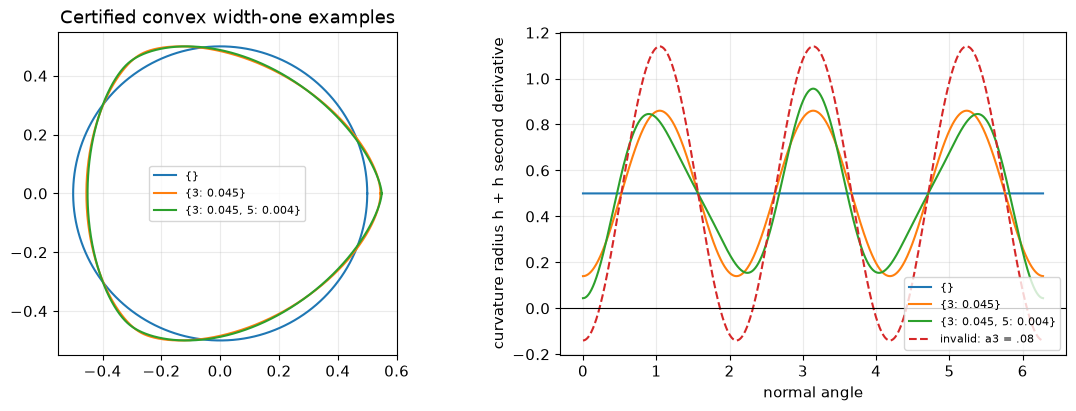

Boundary sampling errors: [1.80107820e-03 4.51481973e-04 1.12946561e-04 2.82413991e-05]


In [4]:
q=np.linspace(0,2*np.pi,1200,endpoint=False)
result=support_shape(q,{3:.045})
if result is None:
    print('Complete support_shape, then rerun this cell.')
else:
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    for coeffs in ({},{3:.045},{3:.045,5:.004}):
        X,rho,exact=support_shape(q,coeffs)
        assert sum((j*j-1)*abs(a) for j,a in coeffs.items())<=.5
        assert rho.min()>=-1e-13
        h=harmonic_data(q,coeffs)[0]
        np.testing.assert_allclose(h+harmonic_data(q+np.pi,coeffs)[0],1.,atol=1e-13)
        np.testing.assert_allclose(area(X),exact,atol=7e-6)
        assert (np.pi-np.sqrt(3))/2<=exact<=np.pi/4+1e-13
        outline(axes[0],X,label=str(coeffs) or 'disk')
        axes[1].plot(q,rho,label=str(coeffs))
        print(f'{coeffs}: analytic area {exact:.9f}, polygon error {abs(area(X)-exact):.2e}')
    _,invalid_rho,_=support_shape(q,{3:.08})
    assert invalid_rho.min()<0
    axes[1].plot(q,invalid_rho,'--',label='invalid: a3 = .08')
    axes[1].axhline(0,color='black',lw=.8)
    axes[0].set_title('Certified convex width-one examples')
    axes[1].set(xlabel='normal angle',ylabel='curvature radius h + h second derivative')
    for ax in axes: ax.legend(fontsize=8)
    plt.show()
    errors=[]
    for count in (60,120,240,480):
        X,_,exact=support_shape(np.linspace(0,2*np.pi,count,endpoint=False),{3:.045})
        errors.append(abs(area(X)-exact))
    assert np.all(np.diff(errors)<0)
    print('Boundary sampling errors:',np.array(errors))


**Explain your observations.** Which constraint fails for a3=.08? Why does adding a first harmonic only translate the body? Can a finite Fourier family contain the Reuleaux triangle exactly?

**Solution guidance:** The curvature radius becomes negative although the antipodal support sum remains one. A first harmonic reconstructs as a constant translation vector and cancels from h+h second derivative and from the area correction. A finite trigonometric expansion is smooth, whereas the Reuleaux triangle has intervals of zero curvature radius in normal coordinates and different regularity at their endpoints. Finite families approximate the problem and need not attain its global minimum.

## Exercise 10.2: Find the covering hexagon and inspect a mixed-area plateau

Allow 35–45 minutes. Let \(m=h-1/2\) and
\(F(\alpha)=m(\alpha)-m(\alpha+\pi/3)+m(\alpha+2\pi/3)\).
Then \(F(\alpha+\pi/3)=-F(\alpha)\). At a zero, solve
\(c\cdot u(\alpha+j\pi/3)=m(\alpha+j\pi/3)\), for \(j=0,1\).
The three supporting strips have common center \(c\), giving a regular
hexagon of inradius \(1/2\).

**Code tasks:** complete `covering_hexagon(h)` using `brentq` on `[0, pi/3]`
(with explicit endpoint-zero handling), solve for `center`, and return
`(alpha, center, vertices)`. The six hexagon vertex angles are
`alpha + pi/6 + j*pi/3`, at radius `1/sqrt(3)` from the center.
The support callback accepts an array of angles.

Plot the translated smooth example and its hexagon, then the centered
Reuleaux triangle and its hexagon. Check containment and all six tangencies.
For the equilateral skeleton T, the sampled Reuleaux boundary R, and the
hexagon H, compute `V(P,-P) = (area(P+(-P))-2*area(P))/2` with the supplied
polygon sum. Explain why the same mixed area can accompany different areas.
Repeat the Reuleaux sampling at 20, 40, and 80 points per arc: which quantity
has a sampling error, and which is constant even for the inscribed polygons?


In [5]:
def covering_hexagon(h):
    def F(alpha):
        vals=np.asarray(h(alpha+np.arange(3)*np.pi/3))-.5
        return vals[0]-vals[1]+vals[2]
    left,right=0.,np.pi/3
    if abs(F(left))<1e-13:
        alpha=left
    elif abs(F(right))<1e-13:
        alpha=right
    else:
        alpha=brentq(F,left,right,xtol=1e-14)
    angles=alpha+np.arange(2)*np.pi/3
    center=np.linalg.solve(directions(angles),h(angles)-.5)
    vertices=center+directions(alpha+np.pi/6+np.arange(6)*np.pi/3)/np.sqrt(3)
    return alpha,center,vertices


**Run, visualize and check.**

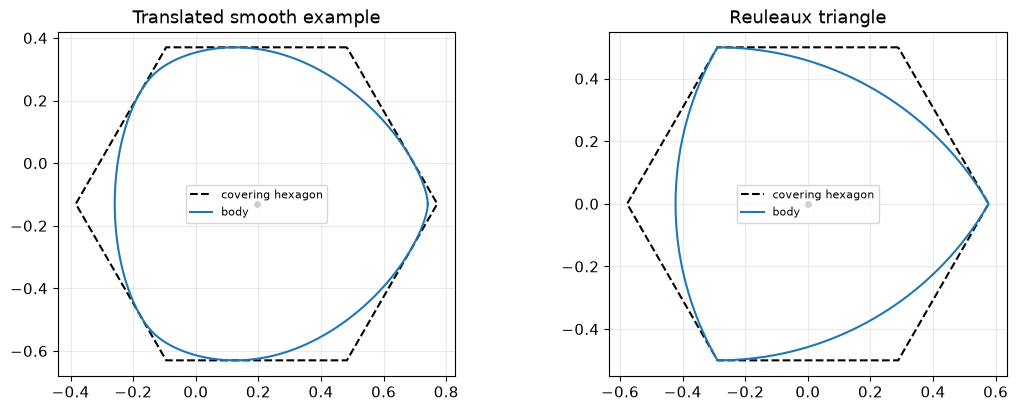

T: area=0.433012702, mixed area with reflection=0.866025404
sampled R: area=0.704691176, mixed area with reflection=0.866025404
H: area=0.866025404, mixed area with reflection=0.866025404
20 points per arc: difference-body area error=1.435e-03
40 points per arc: difference-body area error=3.589e-04
80 points per arc: difference-body area error=8.972e-05


In [6]:
smooth_h=lambda q: harmonic_data(q,{3:.035,5:.006},shift=(.2,-.13))[0]
result=covering_hexagon(smooth_h)
if result is None:
    print('Complete covering_hexagon, then rerun this cell.')
else:
    T=regular_centers(3)
    exact_h=lambda q: reuleaux_support(T,q)
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    for ax,h,label in zip(axes,(smooth_h,exact_h),('Translated smooth example','Reuleaux triangle')):
        alpha,center,H=covering_hexagon(h)
        normals=alpha+np.arange(6)*np.pi/3
        np.testing.assert_allclose(h(normals)-directions(normals)@center,.5,atol=2e-12)
        np.testing.assert_allclose(area(H),np.sqrt(3)/2,atol=2e-12)
        if label.startswith('Translated'):
            q=np.linspace(0,2*np.pi,900,endpoint=False)
            hh,hp,_=harmonic_data(q,{3:.035,5:.006},shift=(.2,-.13))
            u=directions(q); up=np.column_stack((-u[:,1],u[:,0]))
            X=hh[:,None]*u+hp[:,None]*up
        else:
            X=reuleaux_boundary(T,120)
        assert np.max((X-center)@directions(normals).T-.5)<2e-12
        outline(ax,H,color='black',ls='--',label='covering hexagon')
        outline(ax,X,color='tab:blue',label='body')
        ax.scatter(*center,color='black',s=15); ax.set_title(label); ax.legend(fontsize=8)
    plt.show()
    H=covering_hexagon(exact_h)[2]
    for label,P in [('T',T),('sampled R',reuleaux_boundary(T,60)),('H',H)]:
        mixed=(area(polygon_sum(P,-P))-2*area(P))/2
        np.testing.assert_allclose(mixed,np.sqrt(3)/2,atol=2e-10)
        print(f'{label}: area={area(P):.9f}, mixed area with reflection={mixed:.9f}')
    for samples in (20,40,80):
        P=reuleaux_boundary(T,samples)
        difference_area=area(polygon_sum(P,-P))
        print(f'{samples} points per arc: difference-body area error={np.pi-difference_area:.3e}')
        assert 0<np.pi-difference_area<.01


**Explain your observations.** Why is the covering hexagon not itself of constant width? Why can the polygonal approximation have exactly the same mixed area as the curved body, while its difference body is not exactly the disk?

**Solution guidance:** The hexagon has width one only in the six side-normal directions and diameter 2/sqrt(3). Every sampled Reuleaux polygon here contains the three skeleton vertices and lies in the same hexagon. The mixed-area sandwich is therefore exact for each represented polygon; its smaller ordinary area makes its difference-body area slightly smaller than pi. A plot and floating-point root are numerical checks; the sign-change proof establishes the exact covering result.

**Before submitting:** restart the kernel and run all cells. Label the plots and distinguish analytic identities, sampling errors, feasibility checks and global conclusions.